In [217]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=Warning)

/kaggle/input/datasets/yeonseokcho/homework-1/HW1_COIL20.mat


In [218]:
!pip install koreanize-matplotlib

In [219]:
import koreanize_matplotlib # 시각화에 한글 사용
import matplotlib.pyplot as plt

# 문제 1
## (1) 두 클래스의 데이터 생성과 산점도 시각화  

In [220]:
# 파라미터 설정
N = 100 # 샘플 개수

mu1 = np.array([0, 0]) # X-axis 평균 0, Y-axis 평균 0, 좌표를 중심으로 
mu2 = np.array([0, 5]) # X-axis 평균 0, Y-axis 평균 5, 좌표를 중심으로

sigma = np.array([[10, 2], [2, 1]]) 
# [[X의 variance(가로 방향으로 퍼진정도) 10, X와 Y의 Covariance(함께 변하는 정도) 2],
# [Y와 X의 Covariance(함께 변하는 정도) 2, Y의 variance(세로 방향으로 퍼진정도) 1]]
# X축으로 넓게, Y 축으론 좁게 퍼진 분포, XY의 공분산은 2

sigma

array([[10,  2],
       [ 2,  1]])

In [221]:
# X1, X2 데이터 생성
np.random.seed(0) # random seed 설정 

# 평균과 공분산을 따르는 데이터 N개 생성
X1 = np.random.multivariate_normal(mu1, sigma, N)
X2 = np.random.multivariate_normal(mu2, sigma, N)

print(f"X1 shape: {X1.shape}\n")

print("   X 좌표값,    Y 좌표값") # X1 100개 데이터의 X, Y 좌표 
print(X1[:5])
mean_X1 = np.mean(X1, axis=0)
print(f"\nX1 mean: {mean_X1}")

cov_X1 = np.cov(X1, rowvar=False)
print(f"\nX1 Variance-Covariance Matrix:\n {cov_X1}")

X1 shape: (100, 2)

   X 좌표값,    Y 좌표값
[[-5.63452236 -0.8853815 ]
 [-3.44412363  1.00705233]
 [-5.74449449 -1.9770015 ]
 [-2.97687741 -0.74912286]
 [ 0.26133555  0.37390259]]

X1 mean: [-0.01946183  0.10660322]

X1 Variance-Covariance Matrix:
 [[10.52411862  2.16771694]
 [ 2.16771694  1.07302575]]


In [222]:
print(f"X2 shape: {X2.shape}\n")

print("   X 좌표값,    Y 좌표값")
print(X2[:5])

mean_X2 = np.mean(X2, axis=0)
print(f"\nX2 mean: {mean_X2}")

cov_X2 = np.cov(X2, rowvar=False)
print(f"\nX2 Variance-Covariance Matrix:\n {cov_X2}")

X2 shape: (100, 2)

   X 좌표값,    Y 좌표값
[[ 1.20370707  5.06979133]
 [-3.57631255  4.74925055]
 [-1.76710363  3.37095009]
 [ 0.1930646   4.46858451]
 [-0.86864289  4.73954   ]]

X2 mean: [0.46968079 5.01207316]

X2 Variance-Covariance Matrix:
 [[9.29947839 2.06259958]
 [2.06259958 0.97328476]]


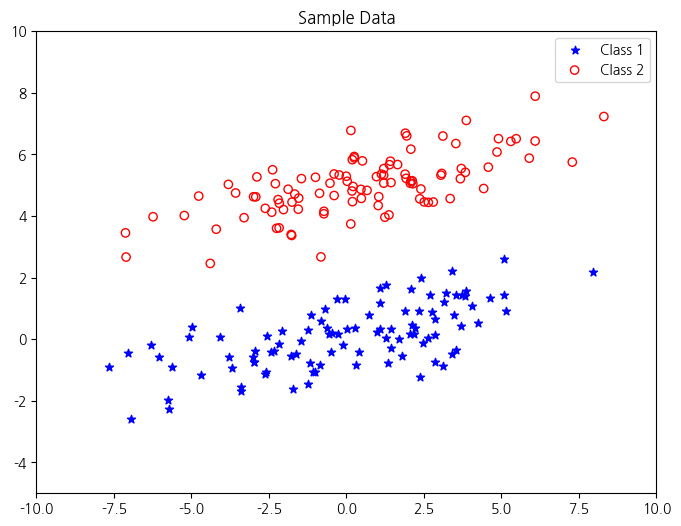

In [223]:
# 산점도 시각화
plt.figure(figsize=(8, 6))

# X1: 파란색 별표
plt.scatter(X1[:, 0], X1[:, 1], marker='*', color='b', label='Class 1')

# X2: 빨간색 빈 원
plt.scatter(X2[:, 0], X2[:, 1], marker='o', facecolors='none', edgecolors='r', label='Class 2')

# axis 지정
plt.axis([-10, 10, -5, 10])

plt.title('Sample Data')
plt.legend(loc='upper right')

plt.show()

## (2) PCA와 LDA의 첫 번째 주성분 벡터

In [224]:
# X1, X2 데이터를 합하여 모집단 데이터 X 만들기
X = np.vstack((X1, X2))
X.shape # 200개의 좌표

(200, 2)

In [225]:
# PCA (주성분 분석)
M = np.mean(X, axis=0) # 모집단 데이터 평균
S = np.cov(X, rowvar=False) # 모집단 데이터 공분산 행렬
print(M)
print(S)

[0.22510948 2.55933819]
[[9.92210618 2.70741233]
 [2.70741233 7.06415331]]


In [226]:
# 고윳값 분해 (Eigen decomposition)
eigenvalues_pca, eigenvectors_pca = np.linalg.eig(S)
print(eigenvalues_pca)
print(eigenvectors_pca)

[11.554511    5.43174849]
[[ 0.85638048 -0.5163453 ]
 [ 0.5163453   0.85638048]]


In [227]:
# 가장 큰 고윳값을 가진 고유벡터가 '첫 번째 주성분 벡터'
max_idx_pca = np.argmax(eigenvalues_pca)
w_pca = eigenvectors_pca[:, max_idx_pca]
print(max_idx_pca)
print(w_pca)

0
[0.85638048 0.5163453 ]


In [228]:
# LDA (선형 판별 분석) 계산 - 클래스 정보 적극 이용
m1 = np.mean(X1, axis=0) # X1 클래스 평균
m2 = np.mean(X2, axis=0) # X2 클래스 평균
print(m1)
print(m2)

[-0.01946183  0.10660322]
[0.46968079 5.01207316]


In [229]:
# Sw 클래스 내 분산 (Within-class scatter)
Sw = N * np.cov(X1, rowvar=False) + N * np.cov(X2, rowvar=False)
Sw

array([[1982.35970108,  423.03165128],
       [ 423.03165128,  204.63105092]])

In [230]:
# Sb 클래스 간 분산 (Between-class scatter)
mean_diff = (m1 - m2).reshape(-1, 1) # 열 벡터로 변환
Sb = np.dot(mean_diff, mean_diff.T) # (m1-m2)*(m1-m2)^T 계산
Sb

array([[ 0.2392605 ,  2.39947439],
       [ 2.39947439, 24.06363535]])

In [231]:
# Sw의 역행렬과 Sb의 곱에 대한 고윳값 분해
eigenvalues_lda, eigenvectors_lda = np.linalg.eig(np.linalg.inv(Sw).dot(Sb))
print(eigenvalues_lda)
print(eigenvectors_lda)

[2.77555756e-17 2.01686482e-01]
[[-0.99506536  0.20319166]
 [ 0.09922166 -0.97913898]]


In [232]:
# 가장 큰 고윳값을 가진 고유벡터가 '첫 번째 판별 벡터'
max_idx_lda = np.argmax(eigenvalues_lda)
w_lda = eigenvectors_lda[:, max_idx_lda]

print(w_lda)

[ 0.20319166 -0.97913898]


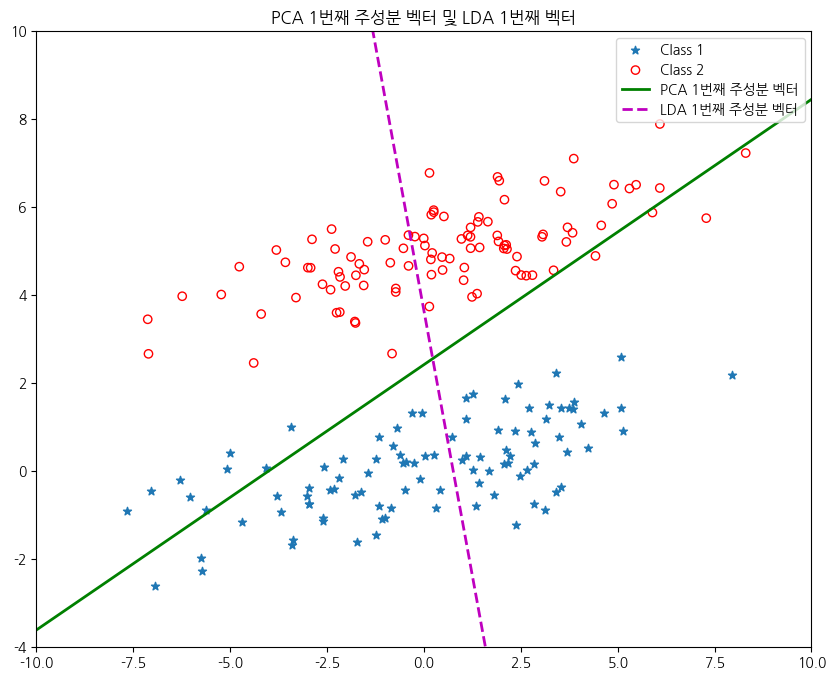

In [233]:
# 시각화 

plt.figure(figsize=(10, 8))

# 기존 데이터 산점도 그리기
plt.scatter(X1[:, 0], X1[:, 1], marker='*', color='C0', label='Class 1')
plt.scatter(X2[:, 0], X2[:, 1], marker='o', facecolors='none', edgecolors='r', label='Class 2')

# 벡터를 화면 끝까지 이어지는 직선으로 그려주는 사용자 정의 함수
def draw_vector_line(w, mean_point, color, label, linestyle='-'):
    slope = w[1] / w[0] # 기울기 (y증가량 / x증가량)
    intercept = mean_point[1] - slope * mean_point[0] # y절편
    x_vals = np.array([-10, 10]) # X축 범위 설정
    y_vals = slope * x_vals + intercept
    plt.plot(x_vals, y_vals, color=color, label=label, linestyle=linestyle, linewidth=2)

# PCA 벡터 그리기 (녹색 실선)
draw_vector_line(w_pca, M, color='g', label='PCA 1번째 주성분 벡터')

# LDA 벡터 그리기 (마젠타색 점선)
draw_vector_line(w_lda, M, color='m', label='LDA 1번째 주성분 벡터', linestyle='--')

# 그래프 축 설정 및 꾸미기
plt.axis([-10, 10, -4, 10]) 
plt.title('PCA 1번째 주성분 벡터 및 LDA 1번째 벡터')
plt.legend(loc='upper right')
plt.show()

## (3) PCA와 LDA의 차이

PCA와 LDA는 모두 차원을 축소하기 위해 새로운 축(벡터)을 찾는 기법이지만, 
'데이터의 클래스 정보를 활용 여부에 따라 두 기법은 나뉘어진다.

1. PCA (주성분 분석, 녹색 실선)
데이터의 클래스 정보를 사용하지 않으므로 비지도 학습에 속한다.
데이터를 사영하였을 때 정보 소실이 가장 적게 일어나는 방향으로 첫번째 주성분 벡터를 찾는다.  
이는 데이터의 '분산이 가장 큰(데이터가 가장 넓게 퍼져 있는) 방향'을 찾는 것이 된다. 
위의 데이터 예에서는 두 클래스가 넓게 퍼저있는 방향에서 합쳐져 이 축으로 데이터를 사영시키면 
전체 데이터의 클래스 1과 2의 데이터가 서로 겹쳐져 효과적인 분리가 되지는 못하는 결과가 얻어졌다. 

2. LDA (선형 판별 분석, 마젠타 점선)
데이터의 클래스 정보를 사용함으로 지도 학습에 속한다.
같은 클래스끼리는 최대한 뭉치게 하고(클래스내 분산 최소화), 서로 다른 클래스의 중심점은 최대한 멀어지게 하는(클래스간 분산 최대화) 
'분류하기 가장 좋은 방향'을 찾는다. 
그 결과 두 클래스를 가장 효과적으로 가로지를 수 있는 방향으로 제1성분 축이 형성되었으며, 
이 축 위로 데이터를 투영시키면 클래스 1과 2를 효과적으로 분류하는게 가능하였다. 

# 문제 2

In [234]:
# 패키지 설치
%pip install mat73

Note: you may need to restart the kernel to use updated packages.


In [235]:
# mat73 패키지 불러오기 
import mat73

In [236]:
# Data Loading
# HW1_COIL20.mat 데이터셋 불러오기 (앞서 캐글 데이터셋 Homework-1에 HW1_COIL20.mat 파일 저장) 

file_path = '/kaggle/input/datasets/yeonseokcho/homework-1/HW1_COIL20.mat'

In [237]:
# HW1_COIL20.mat 데이터셋 확인
data_load = mat73.loadmat(file_path)
print(data_load)

{'X': array([[0.01568627, 0.01568627, 0.01568627, ..., 0.01568627, 0.01568627,
        0.01568627],
       [0.02745098, 0.02745098, 0.02745098, ..., 0.02745098, 0.02745098,
        0.02745098],
       [0.01960784, 0.01960784, 0.01960784, ..., 0.01960784, 0.01960784,
        0.01960784],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]]), 'Xt': array([[0.01568627, 0.01568627, 0.01568627, ..., 0.01568627, 0.01568627,
        0.01568627],
       [0.01960784, 0.01960784, 0.01960784, ..., 0.01960784, 0.01960784,
        0.01960784],
       [0.01568627, 0.01568627, 0.01568627, ..., 0.01568627, 0.01568627,
        0.01568627],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.

In [238]:
# 데이터셋 내 데이터 이름 확인 
print(data_load.keys())

dict_keys(['X', 'Xt', 'Y', 'Yt'])


In [239]:
# DataFrame으로 변환하여 데이터 확인
df_X = pd.DataFrame(data_load['X'])
df_Xt = pd.DataFrame(data_load['Xt'])

df_Y = pd.DataFrame(data_load['Y'])
df_Yt = pd.DataFrame(data_load['Yt'])

print(df_X.shape)
df_X.head()

(280, 1024)


,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0.015686,0.015686,0.015686,0.015686,0.015686,0.018137,0.199265,0.349510,0.322059,0.155882,...,0.349265,0.313235,0.238480,0.133088,0.033088,0.015686,0.015686,0.015686,0.015686,0.015686
1,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,...,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451,0.027451
2,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
3,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,...,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
4,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,...,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529,0.023529


In [240]:
# EDA
pd.set_option('display.float_format', '{:.6f}'.format)

df_X.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
0,280.000000,0.001933,0.006095,0.000000,0.000000,0.000000,0.000000,0.031373
1,280.000000,0.001995,0.006164,0.000000,0.000000,0.000000,0.000000,0.031373
2,280.000000,0.002604,0.011733,0.000000,0.000000,0.000000,0.000000,0.169118
3,280.000000,0.005444,0.031872,0.000000,0.000000,0.000000,0.000000,0.352941
4,280.000000,0.009430,0.040505,0.000000,0.000000,0.000000,0.000000,0.453431


In [241]:
print(df_Xt.shape)
df_Xt.head()

(1160, 1024)


,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.095098,0.303186,...,0.278431,0.134559,0.020098,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686
1,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.160539,0.326961,...,0.303186,0.220833,0.062990,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608,0.019608
2,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.047794,0.294118,0.374510,...,0.355637,0.289461,0.157353,0.029412,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686
3,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686,0.106127,0.325980,0.333824,...,0.348039,0.286520,0.182108,0.048039,0.015686,0.015686,0.015686,0.015686,0.015686,0.015686
4,0.011765,0.011765,0.011765,0.011765,0.011765,0.011765,0.013480,0.176225,0.338725,0.270098,...,0.358824,0.332598,0.229902,0.108088,0.013480,0.011765,0.011765,0.011765,0.011765,0.011765


In [242]:
# EDA
df_Xt.describe().T.head()

,count,mean,std,min,25%,50%,75%,max
0,1160.000000,0.001979,0.006210,0.000000,0.000000,0.000000,0.000000,0.035294
1,1160.000000,0.002297,0.009941,0.000000,0.000000,0.000000,0.000000,0.215686
2,1160.000000,0.002621,0.013638,0.000000,0.000000,0.000000,0.000000,0.317892
3,1160.000000,0.003742,0.021962,0.000000,0.000000,0.000000,0.000000,0.342157
4,1160.000000,0.008908,0.033865,0.000000,0.000000,0.000000,0.000000,0.367157


In [243]:
print(df_Y.shape)
df_Y.head()

(280, 1)


,0
0,1.000000
1,1.000000
2,1.000000
3,1.000000
4,1.000000


In [244]:
print(df_Yt.shape)
df_Yt.head()

# X train data, Y Classes
# Xt test data, Yt Classes

(1160, 1)


,0
0,1.000000
1,1.000000
2,1.000000
3,1.000000
4,1.000000


In [245]:
df_Y.value_counts()
# 20 classes, 14 elements in each class

0        
1.000000     14
2.000000     14
3.000000     14
4.000000     14
5.000000     14
6.000000     14
7.000000     14
8.000000     14
9.000000     14
10.000000    14
11.000000    14
12.000000    14
13.000000    14
14.000000    14
15.000000    14
16.000000    14
17.000000    14
18.000000    14
19.000000    14
20.000000    14
Name: count, dtype: int64

In [246]:
df_Yt.value_counts()
# 20 classes

0        
1.000000     58
2.000000     58
3.000000     58
4.000000     58
5.000000     58
6.000000     58
7.000000     58
8.000000     58
9.000000     58
10.000000    58
11.000000    58
12.000000    58
13.000000    58
14.000000    58
15.000000    58
16.000000    58
17.000000    58
18.000000    58
19.000000    58
20.000000    58
Name: count, dtype: int64

## 1. PCA 계산

In [247]:
# 1. 데이터 불러오기 및 정리
X = data_load['X']
Y = data_load['Y'].flatten()
classes = np.unique(Y)

# PCA
# 데이터 중앙화 (Centering): 각 특성의 평균을 0으로 맞춤
mean_X = np.mean(X, axis=0)
X_centered = X - mean_X

# 공분산 행렬 계산
cov_mat = np.cov(X_centered, rowvar=False)

# 고윳값(eigenvalues)과 고유벡터(eigenvectors) 계산
eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)

# 고윳값을 내림차순으로 정렬 (가장 분산이 큰 축을 찾기 위해)
sorted_index = np.argsort(eigenvalues)[::-1] # 2개의 주성분을 찾기 위해 argsort로 정렬
sorted_eigenvectors = eigenvectors[:, sorted_index]

# 상위 2개의 고유벡터(주성분) 선택
projection_matrix_pca = sorted_eigenvectors[:, 0:2]

# 데이터를 새로운 2차원 공간으로 사영(투영)
X_pca_manual = np.dot(X_centered, projection_matrix_pca)

X_pca_manual[:5]

array([[-2.97475212, -3.75110492],
       [-5.55445765, -1.1741901 ],
       [-5.21547131,  0.1757106 ],
       [-5.06680854, -0.83473245],
       [-1.86811227, -4.03682669]])

## 2. LDA 계산

In [248]:
# LDA 계산
n_features = X.shape[1]
class_labels = np.unique(Y)

# 전체 데이터의 평균
mean_overall = np.mean(X, axis=0)

# 클래스 내 분산 행렬(S_W)과 클래스 간 분산 행렬(S_B) 계산 초기화
S_W = np.zeros((n_features, n_features))
S_B = np.zeros((n_features, n_features))

for c in class_labels:
    X_c = X[Y == c]
    mean_c = np.mean(X_c, axis=0)
    
    # S_W (클래스 내 분산) 누적
    # 수학적 에러(특이 행렬) 방지를 위해 np.cov 사용 후 스케일링
    S_W += np.cov(X_c, rowvar=False) * (X_c.shape[0] - 1)
    
    # S_B (클래스 간 분산) 누적
    n_c = X_c.shape[0]
    mean_diff = (mean_c - mean_overall).reshape(n_features, 1)
    S_B += n_c * (mean_diff).dot(mean_diff.T)

# 행렬 계산 오류(Singular Matrix) 방지를 위한 Ridge 보정(Shrinkage)
shrinkage_coef = 0.5  # 0~1 사이 값 (if, 0=클래스 정보만 사용, 1=PCA)
mu = np.trace(S_W) / n_features 
S_W_reg = (1 - shrinkage_coef) * S_W + (shrinkage_coef * mu) * np.eye(n_features)

# S_W의 역행렬과 S_B의 곱 계산
mat = np.linalg.inv(S_W_reg).dot(S_B)

# 고윳값과 고유벡터 계산
eigenvalues_lda, eigenvectors_lda = np.linalg.eig(mat)

# 고윳값 내림차순 정렬 (실수부만 사용, 복소수 에러 방지)
eigenvalues_lda = np.real(eigenvalues_lda)
eigenvectors_lda = np.real(eigenvectors_lda)

sorted_index_lda = np.argsort(abs(eigenvalues_lda))[::-1]
sorted_eigenvectors_lda = eigenvectors_lda[:, sorted_index_lda]

# 상위 2개의 판별 벡터 선택
projection_matrix_lda = sorted_eigenvectors_lda[:, 0:2]

# 데이터를 새로운 2차원 공간으로 사영(투영)
X_lda_manual = np.dot(X, projection_matrix_lda)

X_lda_manual[:5]

array([[0.77379712, 3.39867119],
       [1.23844272, 3.59011225],
       [1.3196137 , 3.34292514],
       [0.8789783 , 3.44146513],
       [0.81118777, 3.50354669]])

## 3. PCA 및 LDA 결과 시각화

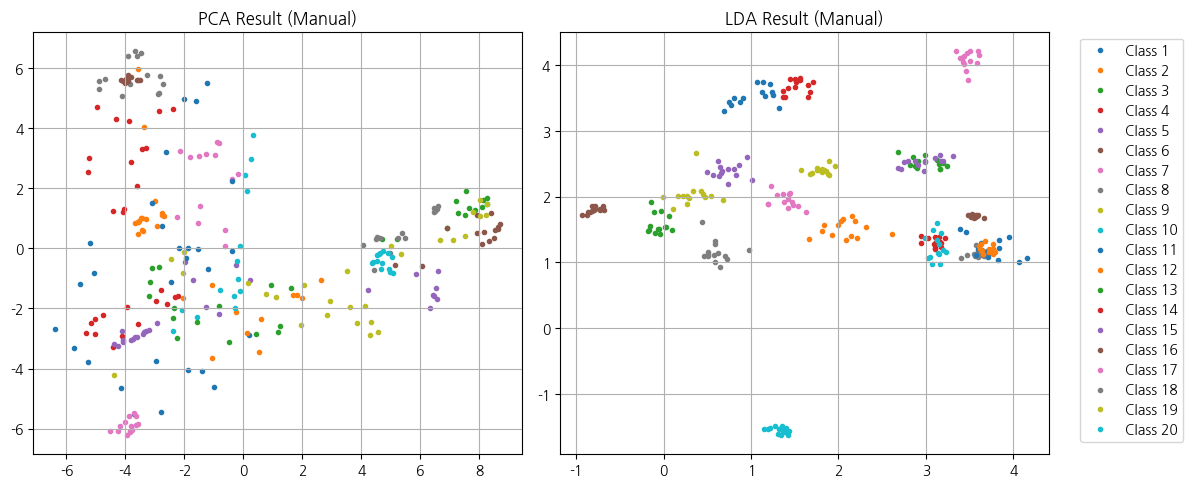

In [249]:
# 시각화 
plt.figure(figsize=(12, 5))

# PCA 결과 왼쪽
plt.subplot(1, 2, 1)
for ii in classes:
    idx = (Y == ii)
    plt.scatter(X_pca_manual[idx, 0], X_pca_manual[idx, 1], label=f'Class {int(ii)}', marker='.')
plt.title('PCA Result (Manual)')
plt.grid(True)

# LDA 결과 오른쪽
plt.subplot(1, 2, 2)
for ii in classes:
    idx = (Y == ii)
    plt.scatter(X_lda_manual[idx, 0], X_lda_manual[idx, 1], label=f'Class {int(ii)}', marker='.')
plt.title('LDA Result (Manual)')
plt.grid(True)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()